In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose


In [118]:
df = pd.read_csv("/Users/cyriaque/timeseries-arma-sarima-forecast/serie", sep= " ", header=None, names=["t", "Xt"])

The model is as follow : X(t) = m(t) + s(t) + Y(t)

where:
- E[Y(t)]=0
- s(t+d) = s(t)
- sum from j=1 to d of s(j) = 0

here d=12 from EDA. Hence q = 6.



Tendency estimation :

Since d is even we can use the following estimator : m(t) = [0.5x_(t-6) + x_(t-5) + ... + x_(t+6)] / 12

In [119]:
weights = np.array([0.5] +[1]*11 + [0.5]) /12
df["trend"] = df["Xt"].rolling(window=13, center=True).apply(lambda x: np.dot(x,weights))
df["trend"].dropna()

6       1.619913
7       1.634055
8       1.598731
9       1.489988
10      1.296460
         ...    
989    10.905636
990    10.965765
991    10.901362
992    10.732093
993    10.687181
Name: trend, Length: 988, dtype: float64

Seasonality estimation :

We can use the following estimator : s(k) = w(k) - mean of w(k)

for k=1,...,d

s(k) = w(k) - mean of w(k)

where w(k) is the average deviation from the trend

In [120]:
df["detrended"] = df["Xt"]-df["trend"]
df["season"] = df.index % 12 +1

w = df.groupby("season")["detrended"].mean()

s_hat = w-w.mean()

df["seasonal"] = df["season"].map(s_hat)
df["de-seasoned"] = df["Xt"] -df["seasonal"]
df["residuals"] = df["Xt"] -df["seasonal"] - df["trend"]

In [121]:
df[5:15]

,t,Xt,trend,detrended,season,seasonal,de-seasoned,residuals
5,6,2.479656,NaN,NaN,6,-2.010474,4.490130,NaN
6,7,-0.435299,1.619913,-2.055213,7,-2.531433,2.096134,0.476220
7,8,-0.554291,1.634055,-2.188347,8,-2.551163,1.996872,0.362817
8,9,-3.152913,1.598731,-4.751644,9,-1.948850,-1.204063,-2.802794
9,10,-1.998976,1.489988,-3.488964,10,-0.862243,-1.136733,-2.626721
10,11,1.303000,1.296460,0.006540,11,0.581009,0.721991,-0.574469
11,12,4.047376,0.994970,3.052406,12,1.790995,2.256381,1.261411
12,13,4.840691,0.696627,4.144064,1,2.721940,2.118751,1.422124
13,14,3.279333,0.468567,2.810766,2,2.852543,0.426790,-0.041777
14,15,2.509693,0.363516,2.146178,3,2.122928,0.386765,0.023250


In [122]:
result = seasonal_decompose(df["Xt"], model="additive", period=12)

In [123]:
result.trend[5:15]


5          NaN
6     1.619913
7     1.634055
8     1.598731
9     1.489988
10    1.296460
11    0.994970
12    0.696627
13    0.468567
14    0.363516
Name: trend, dtype: float64

In [124]:
result.seasonal[5:15]


5    -2.010474
6    -2.531433
7    -2.551163
8    -1.948850
9    -0.862243
10    0.581009
11    1.790995
12    2.721940
13    2.852543
14    2.122928
Name: seasonal, dtype: float64

We got the same results re-computing from scratch and with the statsmodels library.

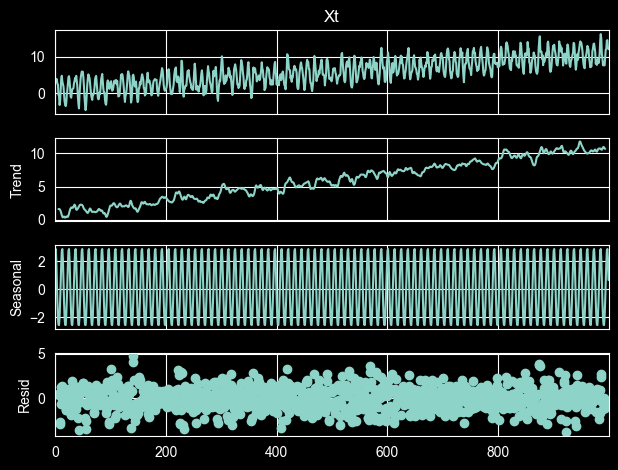

In [125]:
result.plot()
plt.show()

In [128]:
df["Yt"]= df["Xt"] - df["trend"] - df["seasonal"]

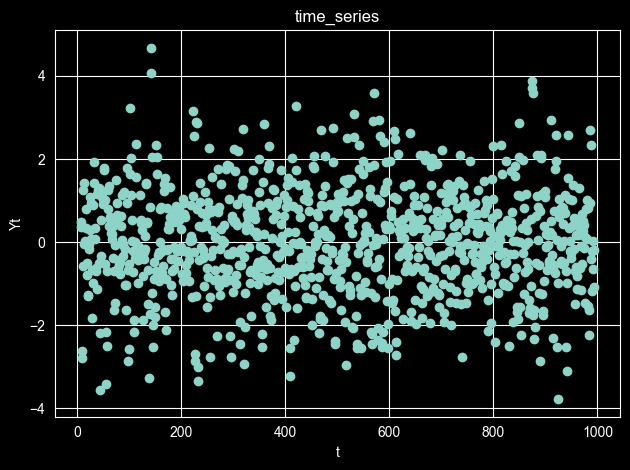

In [130]:
plt.scatter(df["t"][0:1000], df["Yt"][0:1000])
plt.title("time_series")
plt.xlabel("t")
plt.ylabel("Yt")
plt.tight_layout()
plt.show()

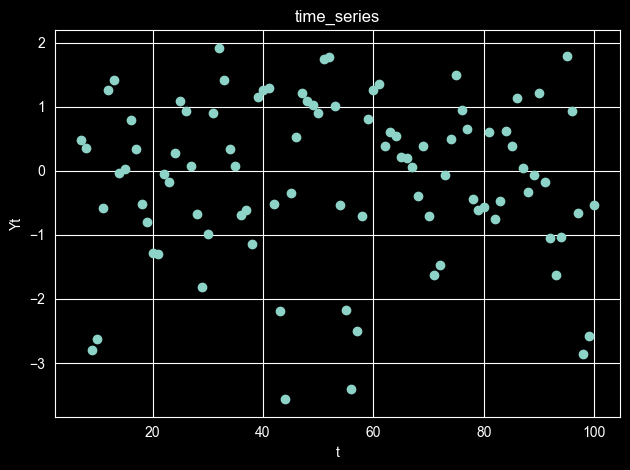

In [131]:
plt.scatter(df["t"][0:100], df["Yt"][0:100])
plt.title("time_series")
plt.xlabel("t")
plt.ylabel("Yt")
plt.tight_layout()
plt.show()

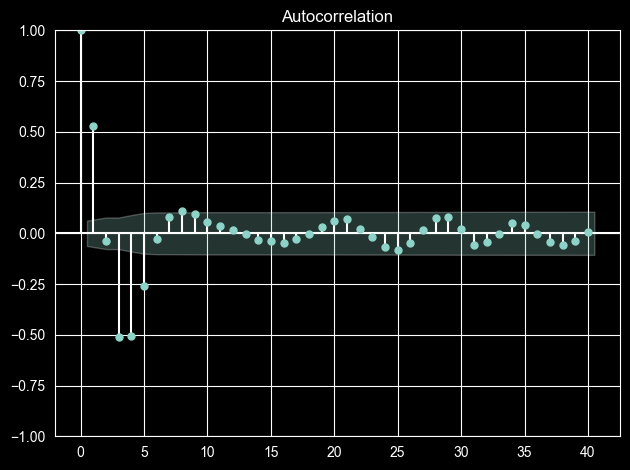

In [132]:
plot_acf(df["Yt"].dropna(), lags=40)
plt.tight_layout()
plt.show()

The ACF drops immediately to near zero and stay in the confidence band so we can assume that the series is stationary.
We can check if our assumption is correct with the Dickey  and Fuller test.

H0 : The series has a unit root --> non-stationarity

H1 : The series is stationary


In [144]:
result = adfuller(df["Yt"].dropna())
print(f"ADF statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF statistic: -12.6080
p-value: 0.0000


In [145]:
result

(np.float64(-12.6079832505304),
 np.float64(1.6794135470670336e-23),
 21,
 966,
 {'1%': np.float64(-3.437137538234527),
  '5%': np.float64(-2.8645366106945414),
  '10%': np.float64(-2.568365556798649)},
 np.float64(2297.545376314163))

Here the p-value is lower than 0.05 so we can reject H0. Hence the series is likely stationary, meaning that we can consider using an ARMA to estimate the series. It is consistent with what we observed from the ACF plot.